# LINTUL3-Gym Tutorial: Spring-Wheat Nitrogen Management

This notebook is the full walkthrough for `lintul3_gym` -- a small, transparent
[Gymnasium](https://gymnasium.farama.org/) environment wrapping PCSE's LINTUL3 crop model. It
covers the package's bundled default dataset (spring wheat, Netherlands, 2006,
[`lintul3_gym/envs/data/springwheat`](../../lintul3_gym/envs/data/springwheat)) and both of its example experiments:

- **Experiment A** -- train and evaluate PPO on one fixed weather season, to see the mechanics
  end-to-end quickly.
- **Experiment B** -- train and evaluate PPO across many years and locations via NASA POWER
  weather, with disjoint train/test years, to see whether a policy generalizes rather than
  memorizes.

Along the way it explains what LINTUL3/PCSE actually need as input, how `lintul3_gym` supplies
those inputs, and how to point the same environment at a different crop.

For a second, fully worked example -- reproducing a published paper's winter-wheat nitrogen
experiment end-to-end, including out-of-distribution climate testing -- see
[`examples/nitrogen-winterwheat/PaperRep-Lintul3gym.ipynb`](../nitrogen-winterwheat/PaperRep-Lintul3gym.ipynb).

## What LINTUL3 and PCSE actually simulate

[PCSE](https://pcse.readthedocs.io/en/stable/) (the Python Crop Simulation Environment) implements
several process-based crop growth models; `lintul3_gym` always drives PCSE's **LINTUL3** model
(LINTUL = Light INTerception and UtiLisation). LINTUL3 is a comparatively simple, generic crop
model: it simulates dry matter production as the result of intercepted light and a light-use
efficiency, extended to simulate crop growth under **water-limited and nitrogen-limited**
conditions -- exactly the regime `lintul3_gym` uses nitrogen-fertilization decisions to manage.

Running any PCSE model -- LINTUL3 included -- always needs three kinds of input, and `lintul3_gym`
is essentially a thin, RL-friendly wrapper around supplying them:

1. **Model parameters** -- a set of *crop* parameters (e.g. light-use efficiency, partitioning
   fractions, temperature sums), *soil* parameters (hydraulic properties), and *site* parameters
   (location-specific ancillary values, e.g. initial water content). These live in the `.crop`,
   `.soil`, and `.site` files of a data directory such as `lintul3_gym/envs/data/springwheat/`.
2. **Weather driving variables** -- daily radiation, temperature, rainfall, etc. `lintul3_gym`
   supports two sources via `WeatherConfig`: a bundled Excel file (`source="excel"`, one fixed
   season) or NASA POWER's public API (`source="nasa"`, any location/year, cached locally under
   `~/.cache/lintul3_gym/nasa_power`).
3. **Agromanagement actions** -- what happens to the crop and when: sowing/emergence date, harvest
   date, and any scheduled field operations (like fertilizer application). In raw PCSE this is a
   YAML `.agro` file; `lintul3_gym` builds the equivalent crop calendar from a `SeasonConfig`
   instead (so you can vary the season without editing YAML), and reserves nitrogen application
   entirely for the RL agent's own `step()` actions -- an `.agro` file's fertilizer schedule, if
   present, is never read as an environment input.

### The bundled `.agro` file, explained

`lintul3_gym/envs/data/springwheat/lintul3_springwheat.agro` is kept purely as a **reference artifact**
(never read by `Lintul3Env` itself) documenting the original PCSE tutorial scenario this dataset
comes from:

```yaml
Version: 1.0
AgroManagement:
- 2006-01-01:
    CropCalendar:
        crop_name: spring-wheat
        crop_start_date: 2006-03-31
        crop_start_type: emergence
        crop_end_date: 2006-10-20
        crop_end_type: earliest
        max_duration: 300
    TimedEvents:
    -   event_signal: apply_n
        name:  Nitrogen application table
        comment: All nitrogen amounts in g N m-2
        events_table:
        - 2006-04-10: {amount: 10, recovery: 0.7}
        - 2006-05-05: {amount:  5, recovery: 0.7}
    StateEvents: null
```

- **`CropCalendar`** -- `crop_start_date`/`crop_start_type` (here: emergence on Mar 31),
  `crop_end_date`/`crop_end_type` (earliest maturity by Oct 20), and `max_duration` as a safety cap
  on episode length. `lintul3_gym`'s `SeasonConfig` mirrors these exact fields (see below) so the
  calendar can be changed in Python instead of YAML.
- **`TimedEvents`** -- actions tied to specific calendar dates. Here a single `apply_n` signal
  drives an `events_table` of `date: {amount, recovery}` pairs: `amount` is nitrogen in g N/m², and
  `recovery` is the *fraction* of applied nitrogen the crop can actually take up (the rest is lost).
- **`StateEvents`** -- actions tied to a model *state* threshold rather than a date (unused here).

`lintul3_gym.policies.ExpertPolicy` reproduces this exact `TimedEvents` schedule (10 g N/m² on Apr
10, 5 g N/m² on May 5) as a fixed-schedule reference baseline -- see the "Reference policies"
section below.

## Setup Environment

In [5]:
# %pip install lintul3-gym==0.1.0 --quiet
# %pip install gymnasium==1.3.0 numpy==2.3.0 pcse==6.0.13 --quiet
# %pip install stable-baselines3==2.9.0 matplotlib==3.11.0 pytest==8.4.2 sphinx==8.2.3 --quiet

In [6]:
# print version of installed packages
import lintul3_gym
print(f"Lintul3-Gym version: {lintul3_gym.__version__}")
import gymnasium as gym
print(f"Gymnasium version: {gym.__version__}")
import numpy as np
print(f"Numpy version: {np.__version__}")
import pcse
print(f"PCSE version: {pcse.__version__}")
import stable_baselines3 as sb3
print(f"Stable Baselines3 version: {sb3.__version__}")
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")

# Notebook was authored/verified against:
# Gymnasium 1.3.0, Numpy 2.3.0, PCSE 6.0.13, Stable-Baselines3 2.9.0, Matplotlib 3.11.0

Lintul3-Gym version: 0.1.0
Gymnasium version: 1.3.0
Numpy version: 2.3.0
PCSE version: 6.0.13
Stable Baselines3 version: 2.9.0
Matplotlib version: 3.11.0


In [7]:
from lintul3_gym.envs.environment import bundled_data_dir

# bundled_data_dir(name) returns any lintul3_gym/envs/data/<name> directory shipped inside the
# installed package -- the same helper used for every bundled dataset, springwheat included
# (its default, `bundled_data_dir()` with no argument) and winterwheat (see the companion
# notebook, examples/nitrogen-winterwheat/PaperRep-Lintul3gym.ipynb).
data_dir = bundled_data_dir("springwheat")
print(f"Spring-wheat data dir: {data_dir}")
print(f"Files in data dir: {sorted(p.name for p in data_dir.iterdir())}")

Spring-wheat data dir: C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat
Files in data dir: ['lintul3_springwheat.agro', 'lintul3_springwheat.crop', 'lintul3_springwheat.site', 'lintul3_springwheat.soil', 'nl1.xlsx']


In [8]:
# Optional: silence a Windows-only PCSE logging quirk. Importing pcse installs a shared
# root-logger RotatingFileHandler at ~/.pcse/logs/pcse.log; on Windows its log-rotation
# rename can fail with a PermissionError if another process (e.g. a second Jupyter kernel)
# still has that file open, printing a harmless but noisy "--- Logging error ---" banner.
# This swaps it for a plain, non-rotating handler so that rename is never attempted.
# Purely cosmetic either way -- remove this cell if you'd rather see PCSE's logging as-is.
from lintul3_gym import silence_pcse_log_rotation

silence_pcse_log_rotation()

## Build the default environment, and inspect its inner workings

`Lintul3Env` auto-discovers whichever single `*.crop`, `*.site`, and `*.soil` file it finds in
`data_dir` -- by extension, not a fixed filename -- so pointing it at any directory shaped like
`lintul3_gym/envs/data/springwheat/` or `lintul3_gym/envs/data/winterwheat/` is enough; see "Adapting this to a
different crop" at the end of this notebook for the full recipe.

In [9]:
from lintul3_gym import Lintul3Env
from lintul3_gym.envs.environment import CROP_FEATURES, WEATHER_FEATURES

environment = Lintul3Env(data_dir=data_dir, decision_interval=7)

print("Resolved input files (auto-discovered by extension):")
for field_name in ("crop", "site", "soil", "weather"):
    print(f"  {field_name:8s} {getattr(environment.paths, field_name)}")

print(f"\nAction space:      {environment.action_space}  (one nitrogen dose, in g N/m^2)")
print(f"Observation space: {environment.observation_space}")
print(f"\nCrop-state features in every observation:    {CROP_FEATURES}")
print(f"Weather features in every observation:       {WEATHER_FEATURES}")

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat: crop, site, soil, weather
Resolved input files (auto-discovered by extension):
  crop     C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat\lintul3_springwheat.crop
  site     C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat\lintul3_springwheat.site
  soil     C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat\lintul3_springwheat.soil
  weather  C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat\nl1.xlsx

Action space:      Box(0.0, 20.0, (1,), float32)  (one nitrogen dose, in g N/m^2)
Observation space: Dict('crop': Box(-inf, inf, (9,), float32), 'management': Box(0.0, inf, (2,), float32), 'weather': Box(-inf, inf, (4,), float32))

Crop-state features in every observation:    ('DVS', 

In [10]:
# Reset starts a fresh LINTUL3 model instance; step() applies one nitrogen dose (g N/m^2) and
# advances `decision_interval` days. Every step's `info["record"]` is a serializable, inspectable
# EpisodeRecord -- nothing about the transition is hidden from the caller.
observation, info = environment.reset(seed=4)
print(f"weather_source={info['weather_source']}  weather_location={info['weather_location']}  weather_year={info['weather_year']}")

weather_source=excel  weather_location=(51.97, 5.67)  weather_year=2006


In [ ]:
# You may repeatedly call step() until the episode ends (terminated or truncated).
# Here, we apply a single nitrogen dose of 0.0 g N/m^2, which is a valid action, and print the resulting reward, record, and rendered state.
observation, reward, terminated, truncated, info = environment.step(np.array([0.0], dtype=np.float32))
print(f"\nReward: {reward:.3f}")
print(f"Record: {info['record']}")
print(f"\n{environment.render()}")


Reward: 0.000
Record: EpisodeRecord(step=0, date=datetime.date(2006, 1, 8), action_nitrogen=0.0, reward=0.0, growth=0.0, nitrogen_cost=0.0, cumulative_nitrogen=0.0, crop={'DVS': 0.0, 'TGROWTH': 0.0, 'LAI': 0.0, 'NUPTT': 0.0, 'TRAN': 0.0, 'TNSOIL': 0.0, 'TRAIN': 0.0, 'TRANRF': 0.0, 'WSO': 0.0}, weather={'IRRAD': 1123000.0, 'TMIN': 0.9, 'TMAX': 3.9, 'RAIN': 0.0})

2006-01-08: N=0.00 g/m², growth=0.00 g/m², reward=0.00


## Reference policies: `ExpertPolicy` and `ZeroNitrogenPolicy`

`ExpertPolicy` reproduces the bundled `.agro` file's exact fertilization schedule (10 g N/m² on
Apr 10, 5 g N/m² on May 5); `ZeroNitrogenPolicy` never fertilizes at all. Both are simple,
inspectable `Policy` implementations (see `lintul3_gym.policies`) -- useful as baselines to compare
a trained RL agent against.

ExpertPolicy's fixed schedule (month, day, dose in g N/m^2): ((4, 10, 10.0), (5, 5, 5.0))


Expert: reward=-12.20, WSO=184.83, N=15.00 g/m2
Zero N: reward=0.00, WSO=47.04, N=0.00 g/m2


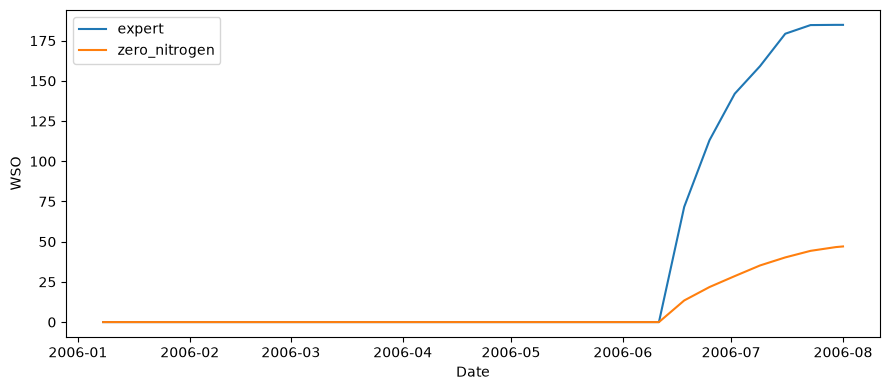

In [12]:
from lintul3_gym.policies import ExpertPolicy, ZeroNitrogenPolicy, evaluate_policy
from lintul3_gym.viz import plot_comparison

print("ExpertPolicy's fixed schedule (month, day, dose in g N/m^2):", ExpertPolicy()._events)

expert = evaluate_policy(environment, ExpertPolicy(), seed=4)
zero_nitrogen = evaluate_policy(environment, ZeroNitrogenPolicy(), seed=4)
print(f"Expert: reward={expert.total_reward:.2f}, WSO={expert.final_wso:.2f}, N={expert.total_nitrogen:.2f} g/m2")
print(f"Zero N: reward={zero_nitrogen.total_reward:.2f}, WSO={zero_nitrogen.final_wso:.2f}, N={zero_nitrogen.total_nitrogen:.2f} g/m2")

results = {
    "expert": expert.history,
    "zero_nitrogen": zero_nitrogen.history,
}
plot_comparison(results)

## Experiment A: Train and Evaluate on the Same Scenario

This experiment trains PPO and evaluates it on the *same* fixed 2006 Excel weather scenario -- the
`environment` built above. Any improvement the RL model shows over the expert/zero-nitrogen
baselines here is expected: the model has effectively memorized this one weather season, so a
strong result is not evidence of generalization. Experiment B, further below, trains and evaluates
on disjoint year/location sets to test that instead.

In [13]:
from lintul3_gym.sb3 import make_discrete_sb3_env, make_training_env, make_eval_env
from lintul3_gym.policies import evaluate_sb3_policy
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

# Wrap the LINTUL3-Gym environment (discrete {0, 20, 40} kg N/ha doses) for Stable Baselines3.
sb3_env = make_discrete_sb3_env(environment)
sb3_env = Monitor(sb3_env, "./logs/experiment_a/")
sb3_env.reset(seed=4)
print(f"Action space: {sb3_env.action_space}")
print(f"Observation space: {sb3_env.observation_space}")

Action space: Discrete(3)
Observation space: Box(-inf, inf, (15,), float32)


In [14]:
# make_training_env wraps make_discrete_sb3_env in Monitor + DummyVecEnv + VecNormalize,
# so PPO trains against batched, normalized observations (norm_reward=True, clip_obs=10).
train_env = make_training_env(environment, log_dir="./logs/experiment_a/")
model = PPO("MlpPolicy", train_env, verbose=1)
model.learn(40_000)

model.save("ppo_experiment_a")
train_env.save("vec_normalize_stats_experiment_a.pkl")

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 31       |
|    ep_rew_mean     | -486     |
| time/              |          |
|    fps             | 45       |
|    iterations      | 1        |
|    time_elapsed    | 44       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 31          |
|    ep_rew_mean          | -436        |
| time/                   |             |
|    fps                  | 45          |
|    iterations           | 2           |
|    time_elapsed         | 90          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015390213 |
|    clip_fraction        | 0.13        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.603      |
|    learning

**Why not just call `model.predict()` on the raw environment?**

A tempting shortcut is `make_discrete_sb3_env(environment)` plus `model.predict(observation)`
directly, skipping `make_eval_env` entirely. This silently breaks two things instead of raising an
error:

- **Dimension mismatch** -- PPO was trained through `DummyVecEnv`, so it expects a batched
  observation with a leading `(1, ...)` dimension. A raw environment's `reset()`/`step()` returns
  a single unbatched vector.
- **Value scaling breakdown** -- `VecNormalize` rescaled every observation the model ever saw
  during training. Raw observations (e.g. `IRRAD` in the millions) are on a completely different
  scale, so the policy network sees out-of-distribution inputs and its action choices become
  unreliable.

Always evaluate through `make_eval_env`, which reconstructs the same wrapper stack training used.

RL Model: reward=53.57, WSO=160.61, N=6.00 g/m2


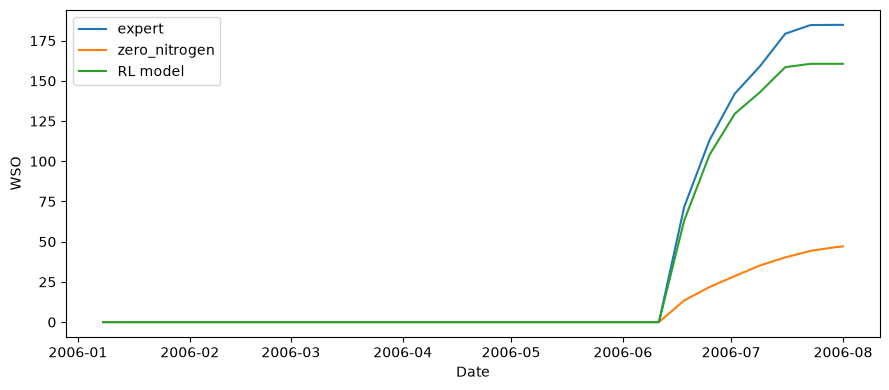

In [15]:
eval_env = make_eval_env(environment, "vec_normalize_stats_experiment_a.pkl")
model = PPO.load("ppo_experiment_a", env=eval_env)

rl_result, = evaluate_sb3_policy(eval_env, model, n_episodes=1)
print(f"RL Model: reward={rl_result.total_reward:.2f}, WSO={rl_result.final_wso:.2f}, N={rl_result.total_nitrogen:.2f} g/m2")

results["RL model"] = rl_result.history
plot_comparison(results)

### Complete comparison (crop, weather, and episode metrics)

**Some variable descriptions**

- `TNSOIL`: the available amount of N in soil the crop can take up
- `WSO`: the weight of the storage organs (grains)
- `LAI`: the leaf area index
- `NUPTT`: the total uptake of N over time -- how well the crop is absorbing N from the soil

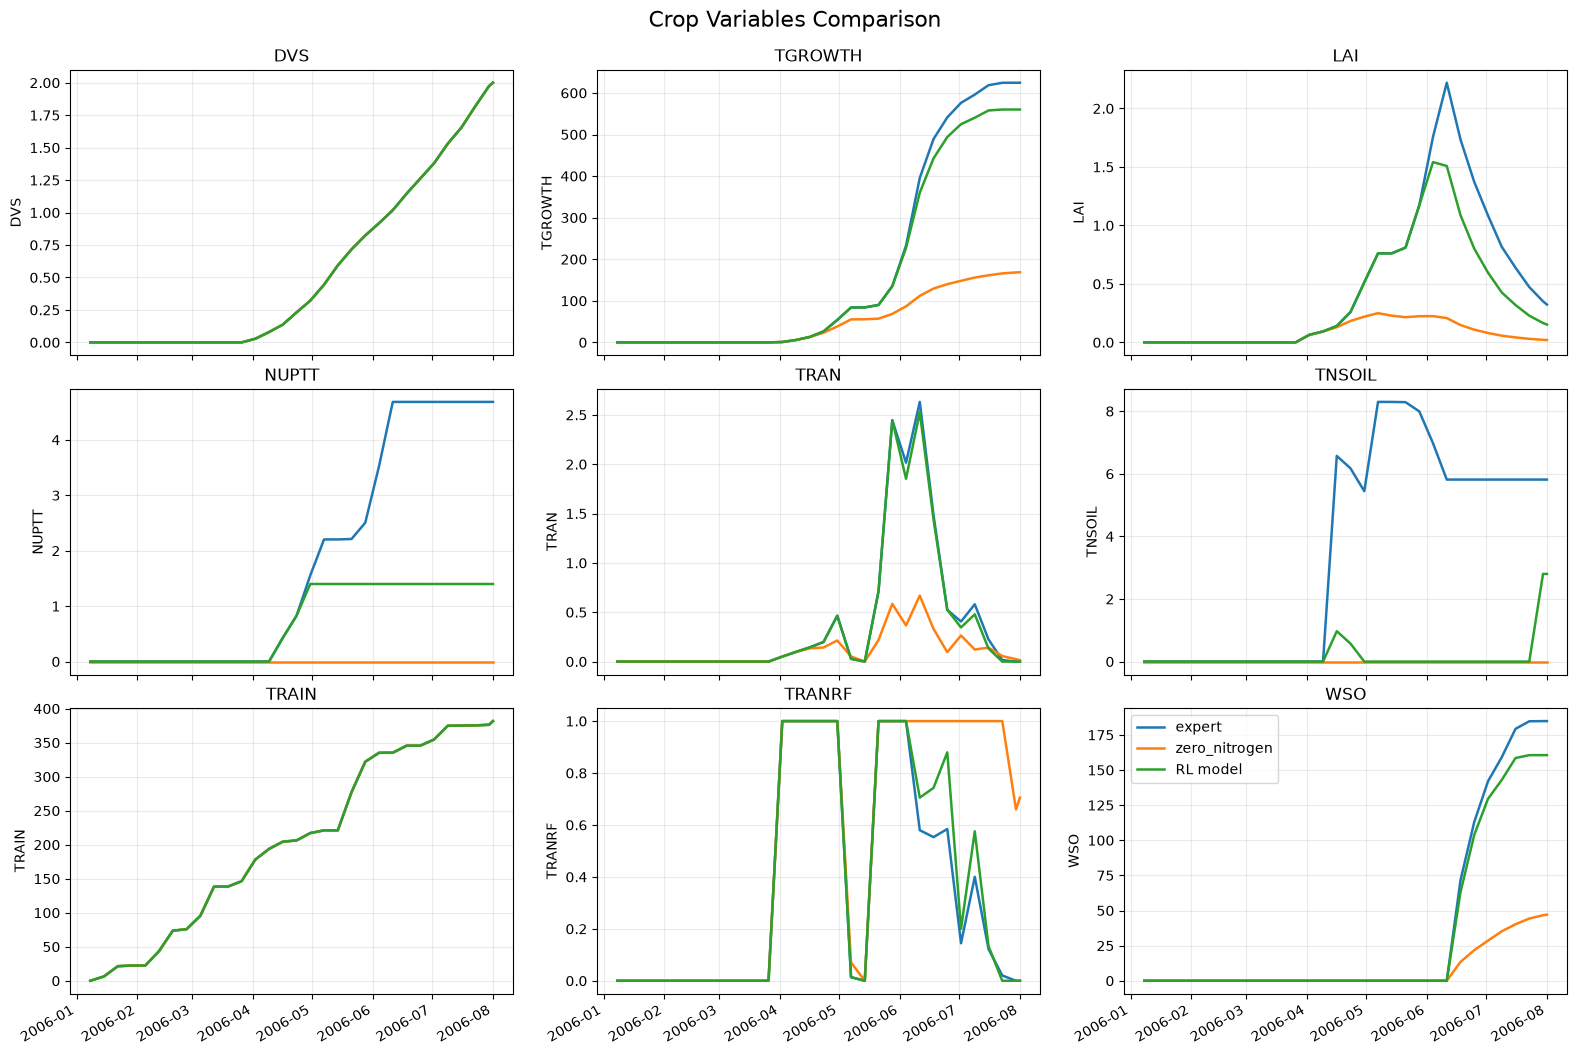

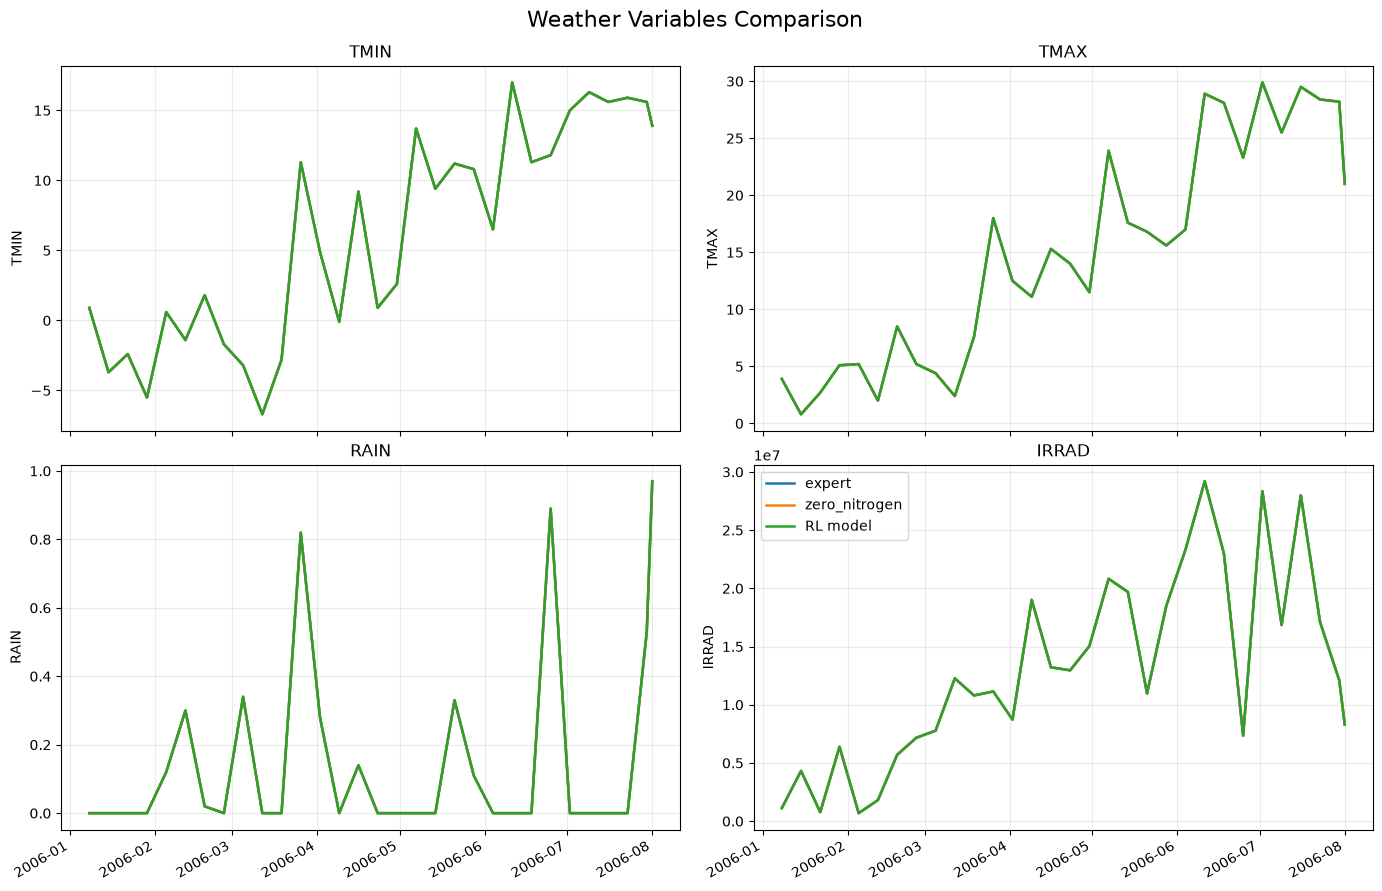

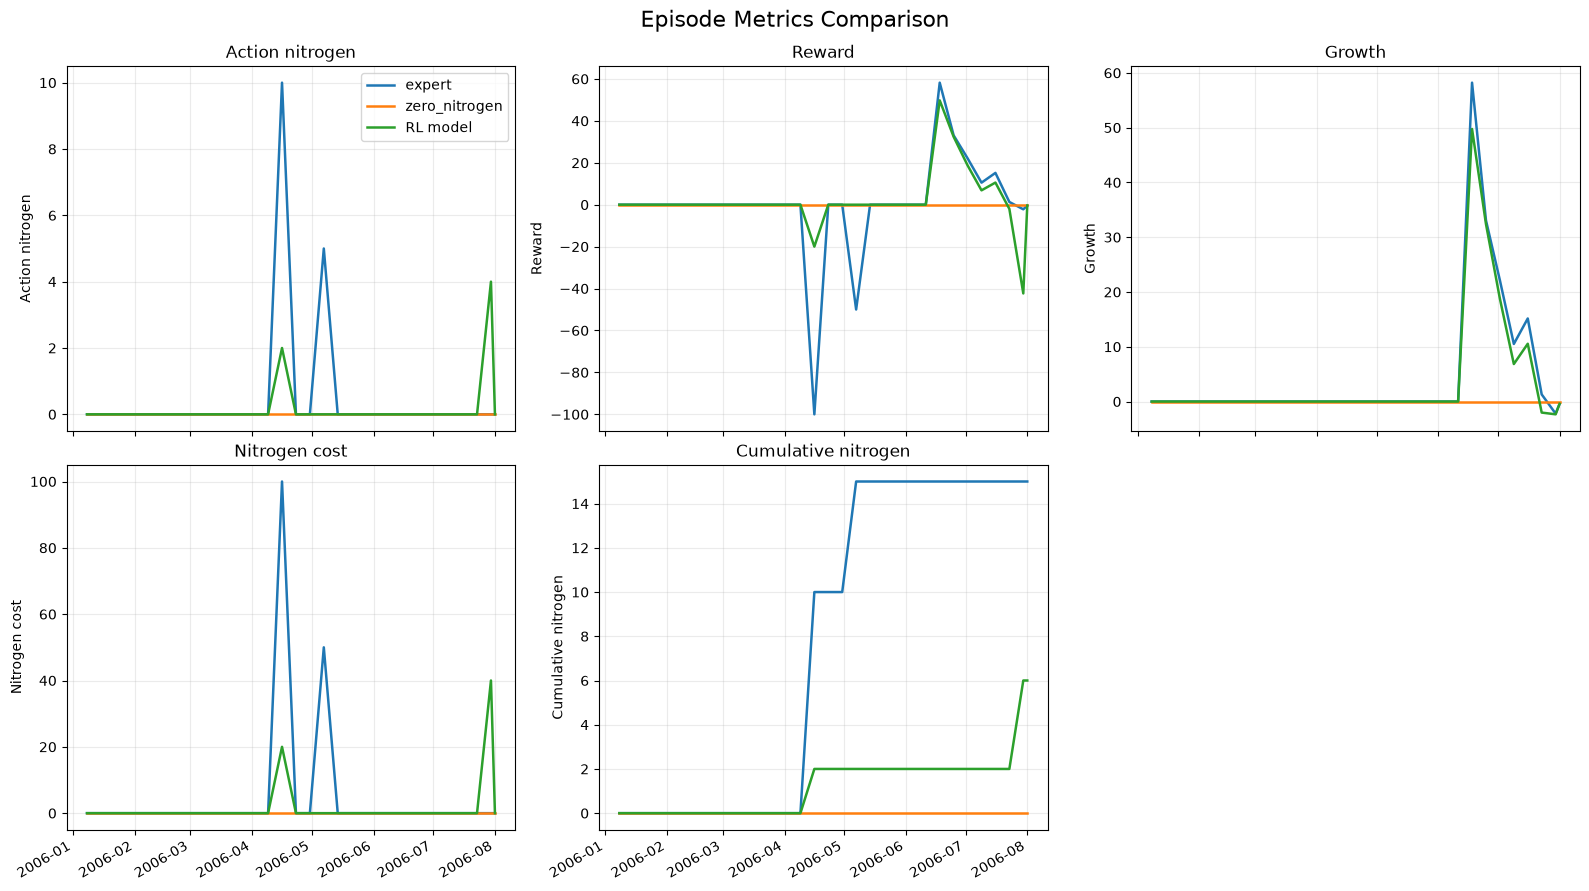

In [16]:
from lintul3_gym.viz import plot_complete_comparison_yearly

plot_complete_comparison_yearly(results)

## Experiment B: Train and Evaluate on Disjoint Year/Location Sets

**Testing generalization, not just memorization:** Experiment A trained and evaluated on one fixed
weather season, so a good result there mostly reflects overfitting to that season. Here we train
on a random mix of odd years (1991-2021) across three nearby Dutch locations, then evaluate on a
*disjoint* held-out set: even years (1990-2022) at the same locations. Comparing RL performance on
the training-distribution check below against the held-out check further down is the actual
generalization test. This still uses the same `lintul3_gym/envs/data/springwheat/` crop/site/soil files as
Experiment A -- only the weather source changes, from the bundled Excel file to NASA POWER.

In [17]:
from lintul3_gym import WeatherConfig

# Train on odd years from 1991-2021 across three nearby Dutch locations, with a random
# (location, year) pair sampled independently each episode.
nasa_environment = Lintul3Env(
    data_dir=data_dir,
    decision_interval=7,
    weather=WeatherConfig(
        source="nasa",
        locations=((52.0, 5.5), (51.5, 5.0), (52.5, 6.0)),
        years=(1991, 1993, 1995, 1997, 1999, 2001, 2003, 2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021),
        random_weather_per_episode=True,
    ),
)
train_env_nasa = make_training_env(nasa_environment, log_dir="./logs/experiment_b/")

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat: crop, site, soil, weather


In [18]:
expert_nasa = evaluate_policy(nasa_environment, ExpertPolicy(), seed=4)
zero_nitrogen_nasa = evaluate_policy(nasa_environment, ZeroNitrogenPolicy(), seed=4)

print(f"Expert: reward={expert_nasa.total_reward:.2f}, WSO={expert_nasa.final_wso:.2f}")
print(f"Zero N: reward={zero_nitrogen_nasa.total_reward:.2f}, WSO={zero_nitrogen_nasa.final_wso:.2f}")

results_nasa = {
    "expert_nasa": expert_nasa.history,
    "zero_nitrogen_nasa": zero_nitrogen_nasa.history,
}

Expert: reward=359.68, WSO=537.94
Zero N: reward=0.00, WSO=28.26


In [20]:
model_nasa = PPO("MlpPolicy", train_env_nasa, verbose=1)
model_nasa.learn(40_000)

model_nasa.save("ppo_experiment_b_nasa")
train_env_nasa.save("vec_normalize_stats_experiment_b_nasa.pkl")

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 31.5     |
|    ep_rew_mean     | -536     |
| time/              |          |
|    fps             | 26       |
|    iterations      | 1        |
|    time_elapsed    | 76       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 31.6        |
|    ep_rew_mean          | -446        |
| time/                   |             |
|    fps                  | 26          |
|    iterations           | 2           |
|    time_elapsed         | 153         |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.027084451 |
|    clip_fraction        | 0.323       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.08       |
|    explained_variance   | 0.113       |
|    learning

RL Model: reward=271.07, WSO=396.11


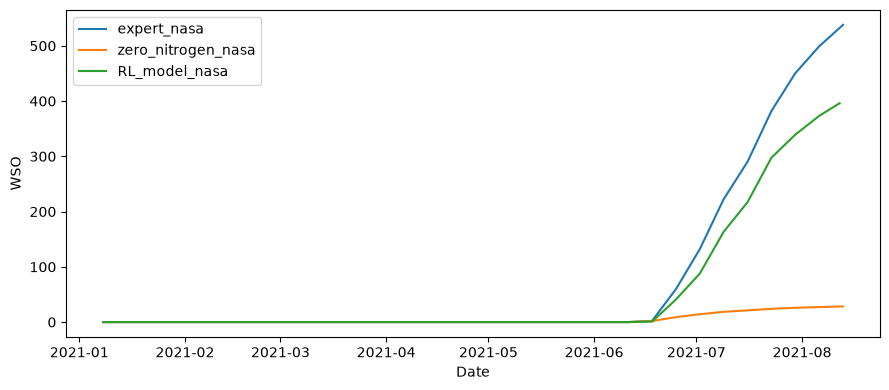

In [27]:
# Sanity check: how does the trained model do on its own training distribution?
eval_env_nasa = make_eval_env(nasa_environment, "vec_normalize_stats_experiment_b_nasa.pkl")
rl_result_nasa, = evaluate_sb3_policy(eval_env_nasa, model_nasa, n_episodes=1)
print(f"RL Model: reward={rl_result_nasa.total_reward:.2f}, WSO={rl_result_nasa.final_wso:.2f}")

results_nasa["RL_model_nasa"] = rl_result_nasa.history
plot_comparison(results_nasa)

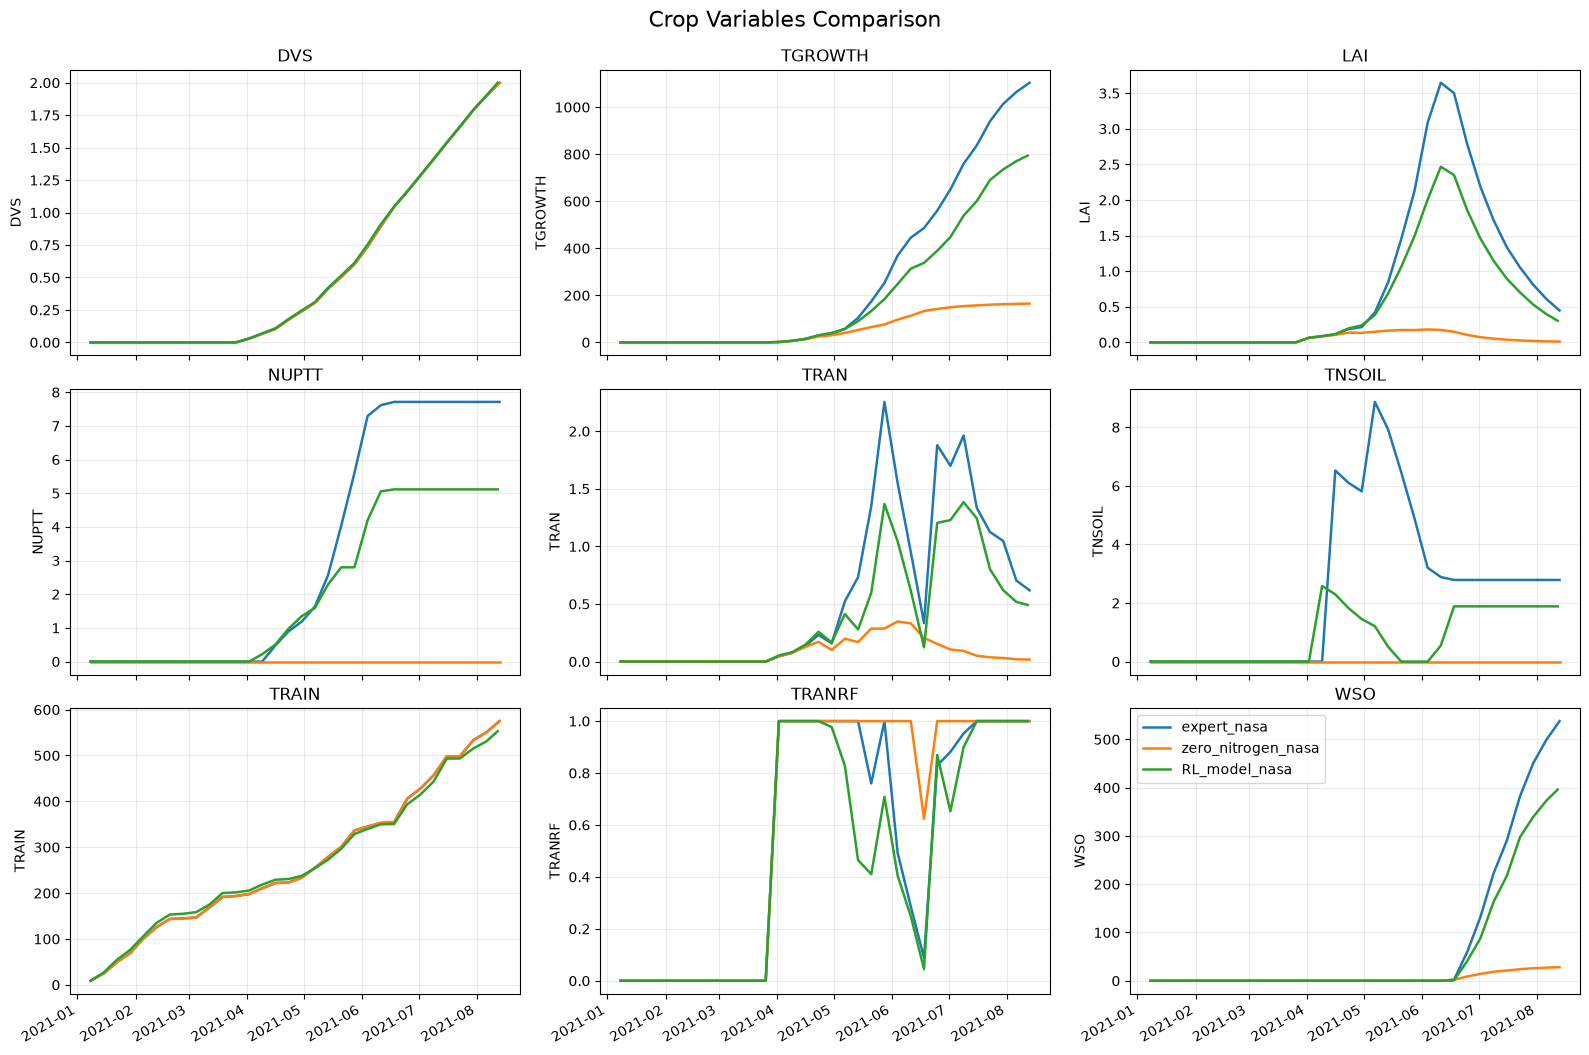

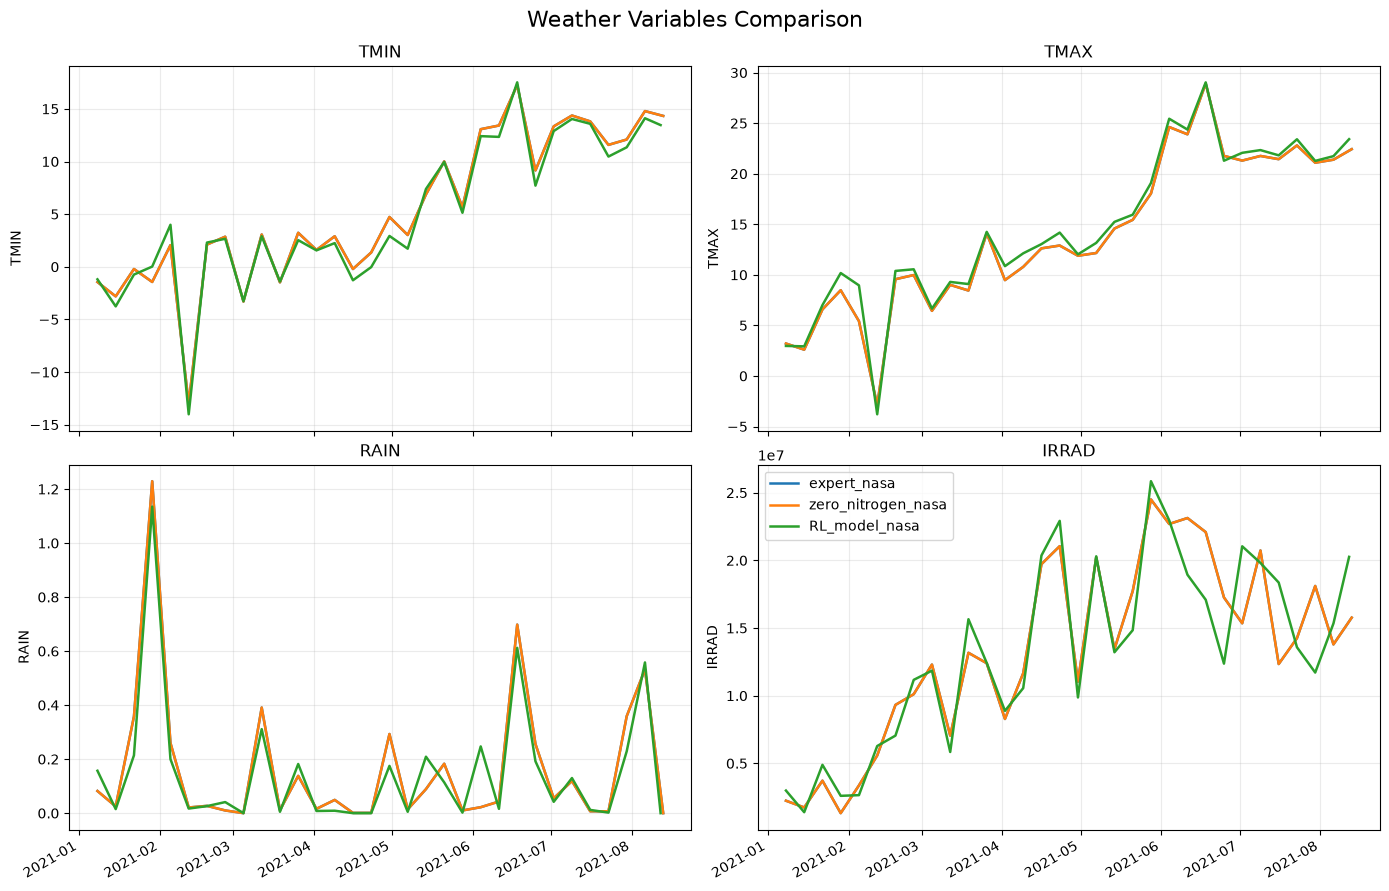

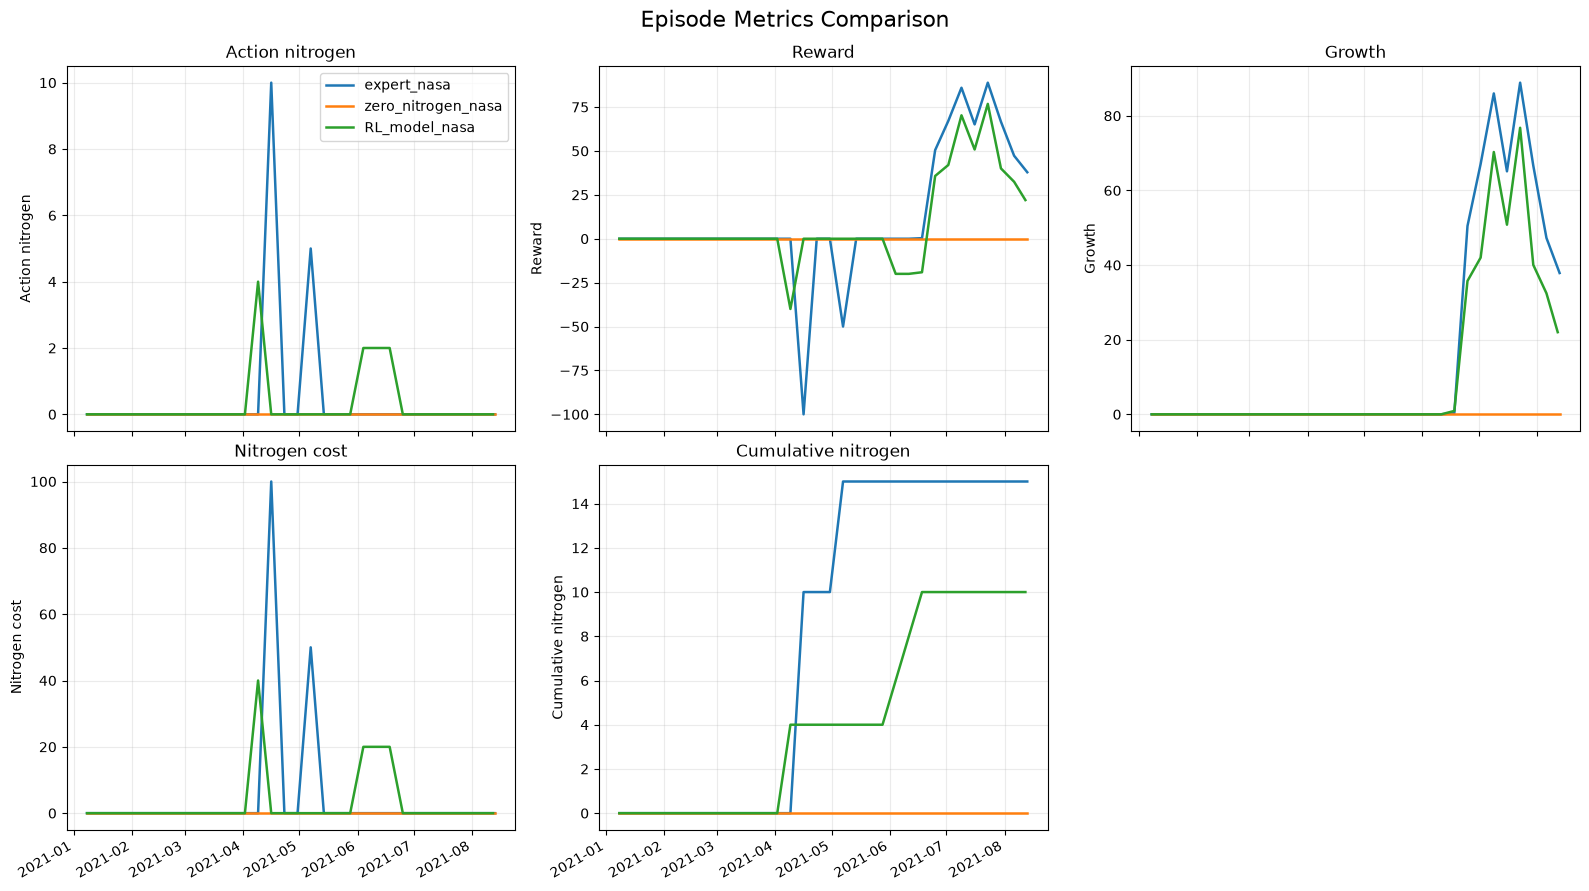

In [28]:
plot_complete_comparison_yearly(results_nasa)

### Held-out evaluation: month-aggregated, multi-year comparison (median + 95% interval)

`deterministic_environment` reuses the same training locations but with
`random_weather_per_episode=False` and a disjoint, held-out set of even years, so every `reset()`
deterministically advances to the next `(location, year)` combination (round-robin) instead of
sampling randomly. `evaluate_policy_over_weather` (expert) and `evaluate_sb3_policy` (RL model)
both run once per combination in that same order, so their results line up one-to-one.

Collecting one history per combination gives multiple years of data per policy, which
`plot_comparison`/`plot_complete_comparison_yearly` can't show on a single calendar-date x-axis.
`plot_complete_comparison_monthly` instead aligns all years by day-of-year and plots the median
value with a shaded 95% interval (2.5th-97.5th percentile), labeled with month names only.

Using LINTUL3 input files from C:\Users\Collins P. Ohagwu\Desktop\pypi_projects\lintul3-gym\lintul3_gym\envs\data\springwheat: crop, site, soil, weather


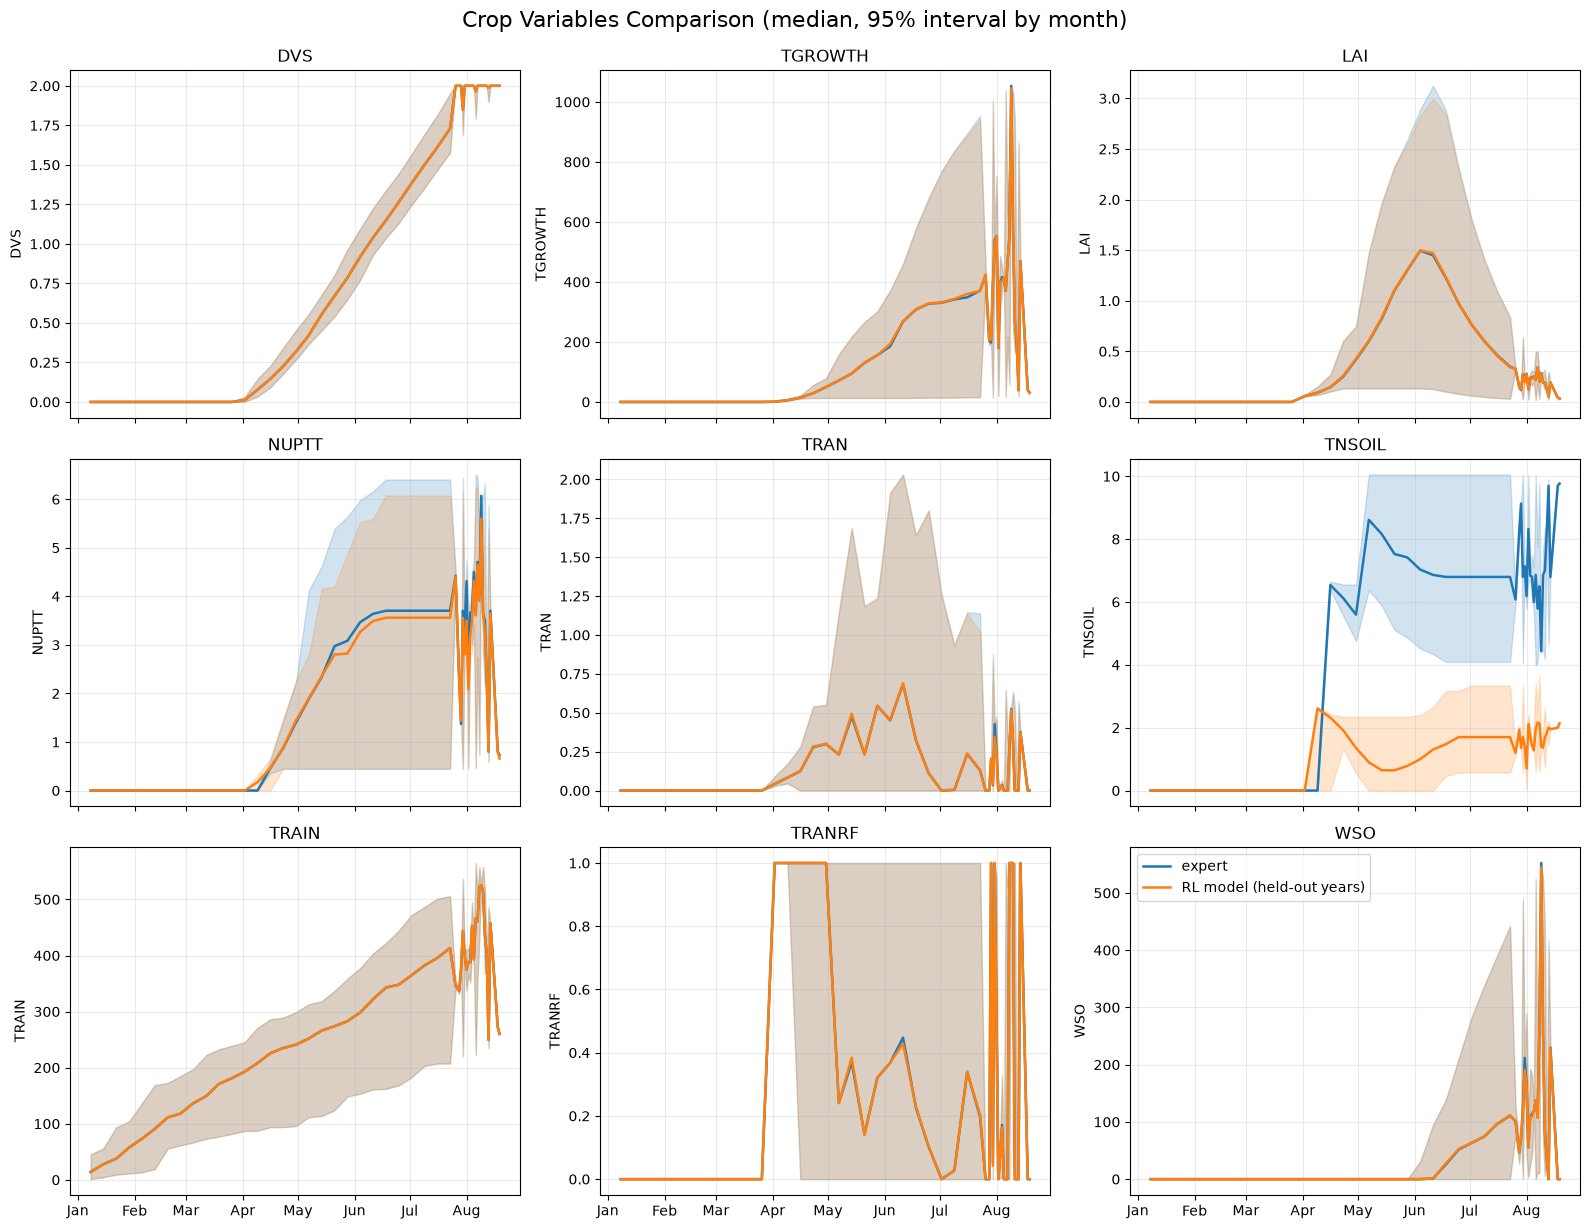

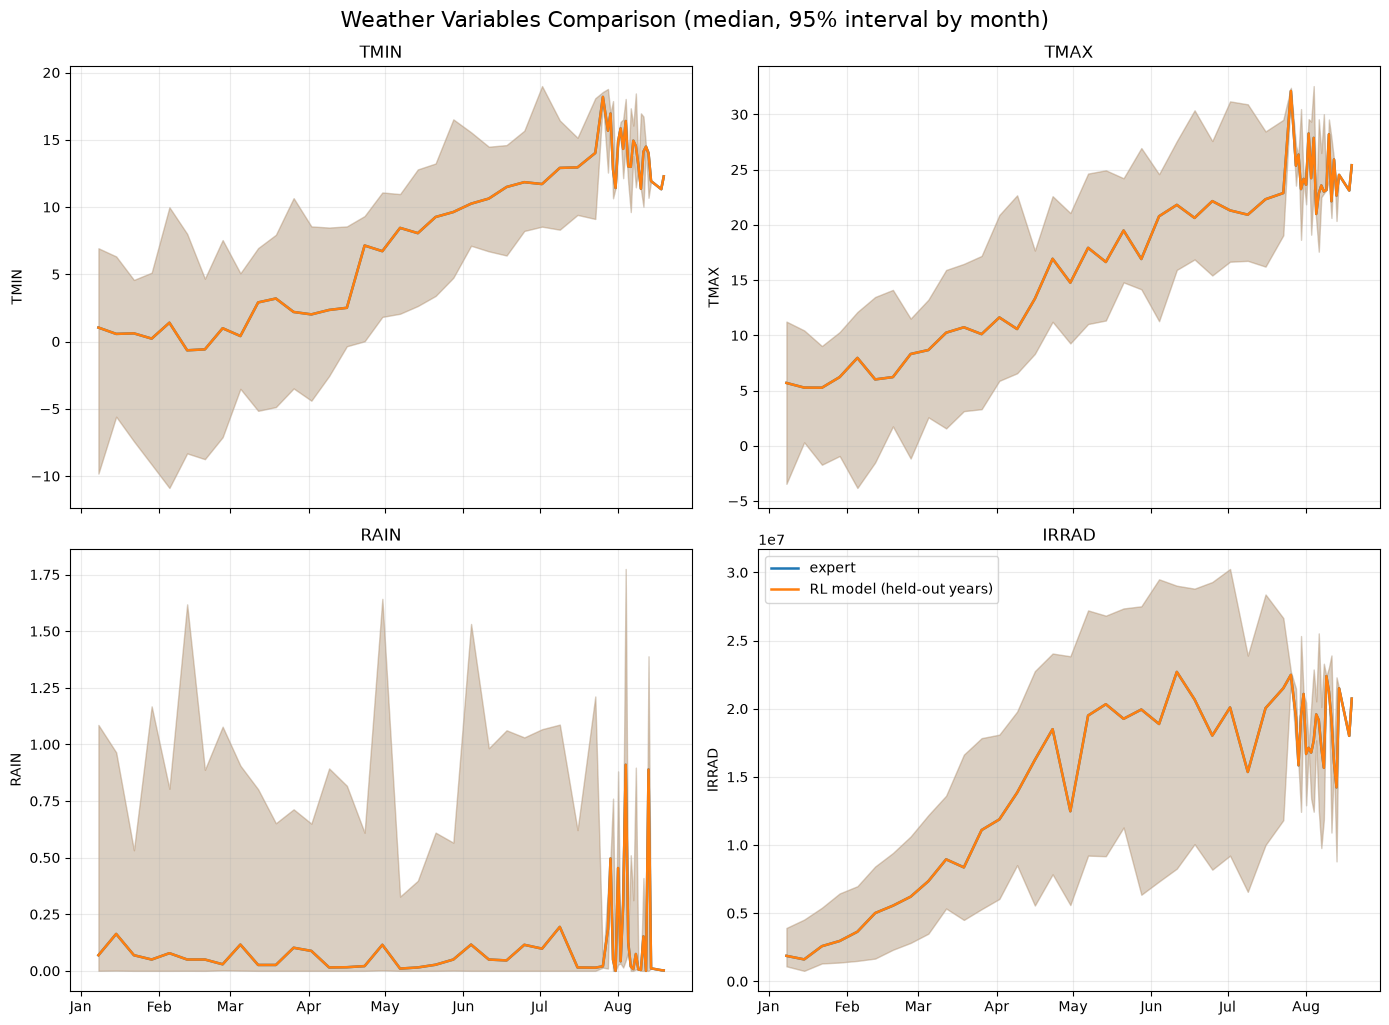

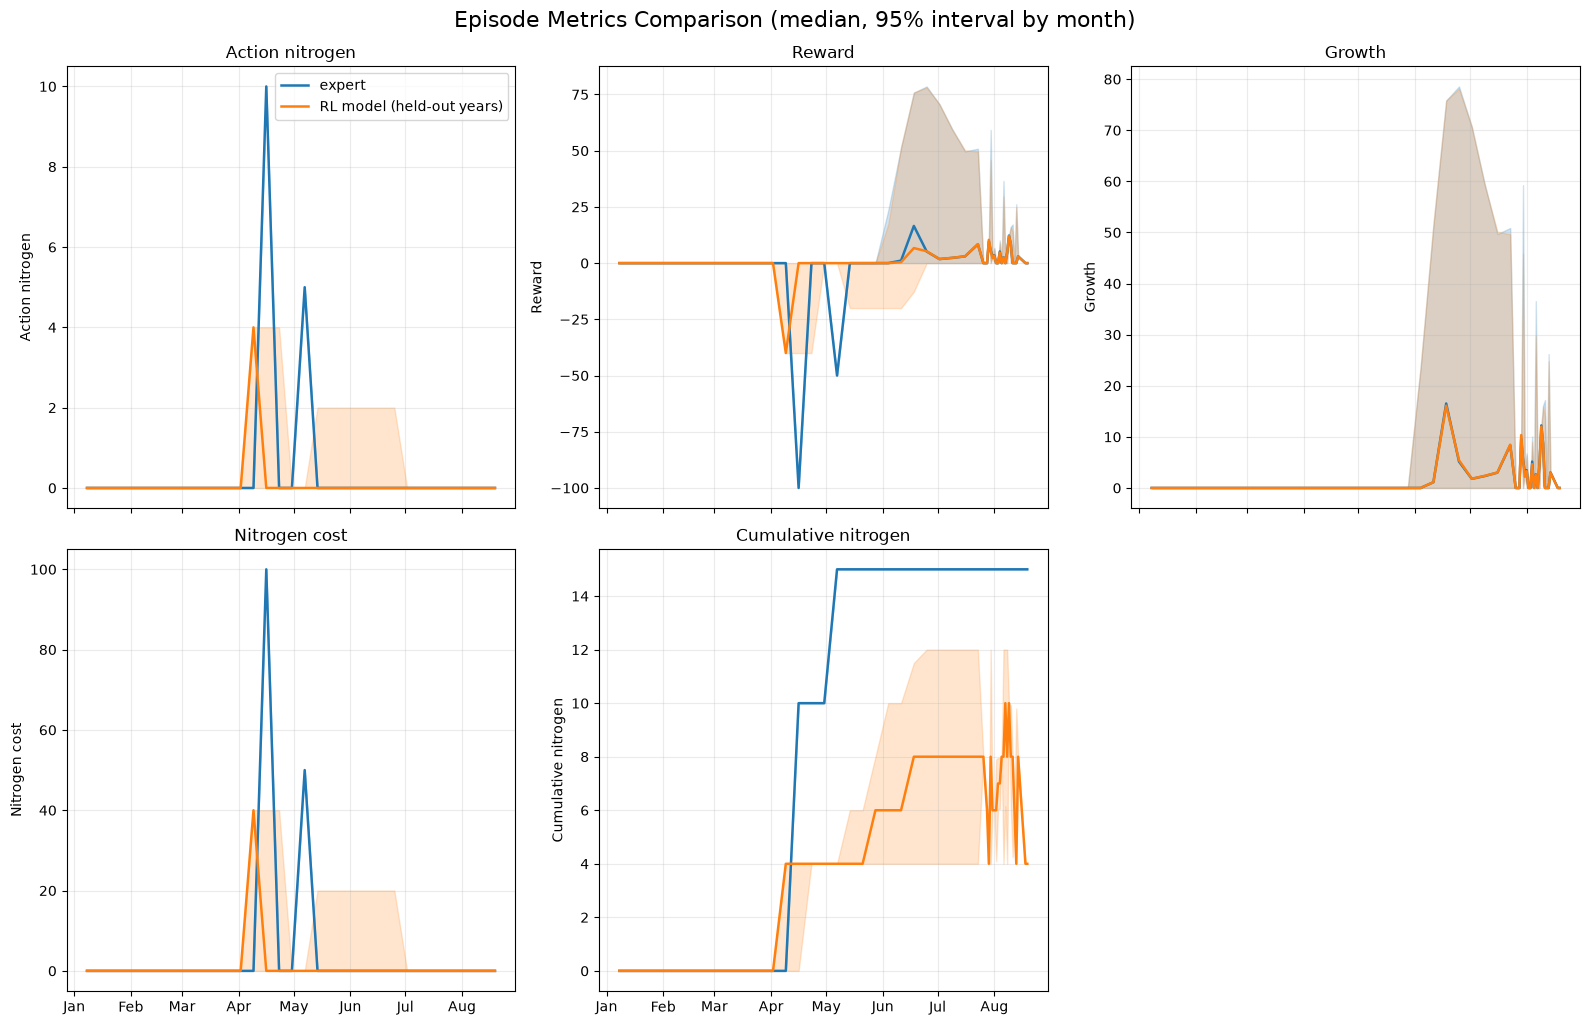

In [29]:
from lintul3_gym.policies import evaluate_policy_over_weather
from lintul3_gym.viz import plot_complete_comparison_monthly

deterministic_environment = Lintul3Env(
    data_dir=data_dir,
    decision_interval=7,
    weather=WeatherConfig(
        source="nasa",
        locations=((52.0, 5.5), (51.5, 5.0), (52.5, 6.0)),
        years=(1990, 1992, 1994, 1996, 1998, 2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022),
        random_weather_per_episode=False,
    ),
)

n_combinations = len(deterministic_environment.weather_config.locations) * len(
    deterministic_environment.weather_config.years
)

# Evaluate through the exact wrapper stack model_nasa was trained with -- reusing the saved
# statistics from training, not the in-memory train_env_nasa, to exercise the same save/load
# path a fresh evaluation session would use.
eval_env_deterministic = make_eval_env(deterministic_environment, "vec_normalize_stats_experiment_b_nasa.pkl")

expert_results = evaluate_policy_over_weather(deterministic_environment, ExpertPolicy())
rl_results = evaluate_sb3_policy(eval_env_deterministic, model_nasa, n_episodes=n_combinations)

monthly_results = {
    "expert": [result.history for result in expert_results],
    "RL model (held-out years)": [result.history for result in rl_results],
}
plot_complete_comparison_monthly(monthly_results)

## Adapting this to a different crop

Everything above generalizes beyond spring wheat: `Lintul3Env` only needs a directory containing
exactly one `*.crop`, one `*.site`, and one `*.soil` file (any filename -- they're discovered by
extension, not a fixed name), plus a matching `SeasonConfig` for the crop calendar. `nl1.xlsx` is
only required if you want `WeatherConfig(source="excel")`; NASA POWER weather needs no local file
at all.

**Worked examples in this repo:**

- [`lintul3_gym/envs/data/springwheat/`](../../lintul3_gym/envs/data/springwheat) -- this notebook (spring wheat, Netherlands,
  2006).
- [`lintul3_gym/envs/data/winterwheat/`](../../lintul3_gym/envs/data/winterwheat) -- winter wheat, Netherlands + France,
  1990-2021, reproducing [Kallenberg et al. (2023)](https://doi.org/10.1017/eds.2023.28); see its
  `README.md` for the full parameter provenance and
  [`examples/nitrogen-winterwheat/PaperRep-Lintul3gym.ipynb`](../nitrogen-winterwheat/PaperRep-Lintul3gym.ipynb)
  for the matching notebook.

**Where to find (or build) more LINTUL3 datasets:**

- [PCSE's own documentation](https://pcse.readthedocs.io/en/stable/) ships further worked-example
  parameter sets alongside its user guide.
- [WUR-AI/PCSE-Gym](https://github.com/WUR-AI/PCSE-Gym) -- the source of this repo's winter-wheat
  dataset -- has additional crop configurations, but most of them (`crops.yaml`, `wheat.yaml`,
  `SUG0601.CAB`) are in **WOFOST** format (`YAMLCropDataProvider`/`CABOFileReader`), for PCSE's
  WOFOST model rather than LINTUL3. They aren't a drop-in for `Lintul3Env` -- which only ever runs
  `pcse.models.LINTUL3` -- without first translating their parameters into the plain
  `PCSEFileReader` `.crop`/`.site`/`.soil` text format used here.

Once you have a parameter set, the pattern is the same one used throughout this notebook:

```python
season = SeasonConfig(
    campaign_start=..., crop_start=..., crop_end=..., crop_name="my-crop",
    crop_start_type="emergence", crop_end_type="earliest", max_duration=...,
)
env = Lintul3Env(data_dir="path/to/my/crop/data", season=season, decision_interval=7)
```